<a href="https://colab.research.google.com/github/k1o1r1o1u1/campus-events/blob/main/Ban_Lam_Lai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# DATA PREPARATION

In [2]:
# import zipfile
# import os
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import ctypes
# import gc
# from tqdm import tqdm
# import pickle
# from scipy import stats
# import collections
# import warnings
# warnings.filterwarnings("ignore", category=DeprecationWarning)

# # Định nghĩa đường dẫn
# # input_dir = "/santander_synthetic_sample.csv"
# # output_dir = "/kaggle/working/"

# # Danh sách file cần giải nén
# # zip_files = [
# #     "train_ver2.csv.zip",
# #     "test_ver2.csv.zip",
# #     "sample_submission.csv.zip"
# # ]
# from sklearn.model_selection import train_test_split
# # # Giải nén từng file
# # for zip_file in zip_files:
# #     zip_path = os.path.join(input_dir, zip_file)
# #     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
# #         zip_ref.extractall(output_dir)

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Load the dataset (adjust the path if needed)
input_file = "/santander_synthetic_sample.csv"
df = pd.read_csv(input_file)

print("Original dataset shape:", df.shape)

# Suppose the last column is the target (adjust if your dataset differs)
target_column = df.columns[-1]

# Split features and target
X = df.drop(columns=[target_column])
y = df[target_column]

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if len(y.unique()) < 20 else None
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

# Optional: reassemble DataFrames
df = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)


Original dataset shape: (5000, 48)
Training set shape: (4000, 47) (4000,)
Testing set shape: (1000, 47) (1000,)


# DATA PREPROCESSING

# Tối ưu loại dữ liệu để giảm độ lớn

In [5]:
def reduce_memory_usage(df, verbose=True):
    numerics = ["int8", "int16", "int32", "int64", "float16", "float32", "float64"]
    start_mem = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if (
                    c_min > np.finfo(np.float16).min
                    and c_max < np.finfo(np.float16).max
                ):
                    df[col] = df[col].astype(np.float16)
                elif (
                    c_min > np.finfo(np.float32).min
                    and c_max < np.finfo(np.float32).max
                ):
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024 ** 2
    if verbose:
        print(
            "Mem. usage decreased to {:.2f} Mb ({:.1f}% reduction)".format(
                end_mem, 100 * (start_mem - end_mem) / start_mem
            )
        )
    return df

In [6]:
# Trước khi giảm
before_df = df.memory_usage().sum() / 1024 ** 2  # Đổi sang MB
before_df_test = df_test.memory_usage().sum() / 1024 ** 2

# Giảm bộ nhớ
df = reduce_memory_usage(df)
df_test = reduce_memory_usage(df_test)

# Sau khi giảm
after_df = df.memory_usage().sum() / 1024 ** 2
after_df_test = df_test.memory_usage().sum() / 1024 ** 2

print("So sanh truoc va sau khi giam")
print("Tap train: ", before_df, " - ",after_df)
print("Tap test: ", before_df_test, " - ",after_df_test)

Mem. usage decreased to 0.61 Mb (58.9% reduction)
Mem. usage decreased to 0.15 Mb (58.9% reduction)
So sanh truoc va sau khi giam
Tap train:  1.495361328125  -  0.614166259765625
Tap test:  0.37384033203125  -  0.15354156494140625


# Xử lí dữ liệu NULL

## age

In [7]:
df['age'] = pd.to_numeric(df['age'], errors="coerce")
df_test['age'] = pd.to_numeric(df_test['age'], errors="coerce")

df['age'] = df['age'].fillna(df['age'].mean())
df_test['age'] = df_test['age'].fillna(df['age'].mean())

## antiguedad

In [8]:
df['antiguedad'] = pd.to_numeric(df['antiguedad'], errors="coerce")
df_test['antiguedad'] = pd.to_numeric(df_test['antiguedad'], errors="coerce")

df['antiguedad'] = df['antiguedad'].fillna(df['antiguedad'].mean())
df_test['antiguedad'] = df_test['antiguedad'].fillna(df['antiguedad'].mean())

df.loc[df["antiguedad"] < 0, "antiguedad"] = 0
df_test.loc[df_test.antiguedad <0, "antiguedad"] = 0

## renta

In [9]:
df['renta'] = pd.to_numeric(df['renta'], errors='coerce')
df_test['renta'] = pd.to_numeric(df_test['renta'], errors='coerce')

mean_gross_classified_df = df.groupby(['nomprov', 'segmento'])['renta'].mean().reset_index()
mean_gross_classified_df.rename(columns={'renta': 'mean_gross_classified'}, inplace=True)
overall_renta = df['renta'].mean()
mean_gross_classified_df['mean_gross_classified'] = mean_gross_classified_df['mean_gross_classified'].fillna(overall_renta)
lookup_dict = mean_gross_classified_df.set_index(['nomprov', 'segmento'])['mean_gross_classified'].to_dict()

def fill_renta(row):
    if pd.isna(row['renta']):
        if pd.isna(row['nomprov']) or pd.isna(row['segmento']):
            return overall_renta
        key = (row['nomprov'], row['segmento'])
        return lookup_dict.get(key, overall_renta)

    return row['renta']

df['renta'] = df.apply(fill_renta, axis=1)
df_test['renta'] = df_test.apply(fill_renta, axis=1)

## ind_nomina_ult1 và ind_nom_pens_ult1

In [10]:
df.fillna(value={'ind_nomina_ult1':0,'ind_nom_pens_ult1':0}, inplace=True)

## indrel_1mes

In [13]:
map_dict = { 1.0  : "1",
            "1.0" : "1",
            "1"   : "1",
            "3.0" : "3",
            "P"   : "P",
            3.0   : "3",
            2.0   : "2",
            "3"   : "3",
            "2.0" : "2",
            "4.0" : "4",
            "4"   : "4",
            "2"   : "2"}

df['indrel_1mes'] = df['indrel_1mes'].fillna("P")
df['indrel_1mes'] = df['indrel_1mes'].apply(lambda x: map_dict.get(x, x))
df['indrel_1mes'] = df['indrel_1mes'].astype("category")

df_test['indrel_1mes'] = df_test['indrel_1mes'].fillna("P")
df_test['indrel_1mes'] = df_test['indrel_1mes'].apply(lambda x: map_dict.get(x, x))
df_test['indrel_1mes'] = df_test['indrel_1mes'].astype("category")

## ind_nuevo

In [14]:
df['ind_nuevo'] = df['ind_nuevo'].astype(float)
df_test['ind_nuevo'] = df_test['ind_nuevo'].astype(float)
df['ind_nuevo'] = df['ind_nuevo'].fillna(1.0)
df_test['ind_nuevo'] = df_test['ind_nuevo'].fillna(1.0)

## indrel

In [15]:
df['indrel'] = df['indrel'].astype(float)
df_test['indrel'] = df_test['indrel'].astype(float)
df['indrel'] = df['indrel'].fillna(1.0)
df_test['indrel'] = df_test['indrel'].fillna(1.0)

## ind_actividad_cliente

In [16]:
df['ind_actividad_cliente'] = df['ind_actividad_cliente'].astype(float)
df_test['ind_actividad_cliente'] = df_test['ind_actividad_cliente'].astype(float)

## indfall

In [17]:
df['indfall'] = df['indfall'].fillna("N")
df_test['indfall'] = df_test['indfall'].fillna("N")

# Xử lí outlier và chuẩn hóa min-max đối với các cột có dạng numeric

Nhóm em chỉ xử lí outlier đối với 3 cột duy nhất có dạng numerical là age, antiguedad và renta

## age

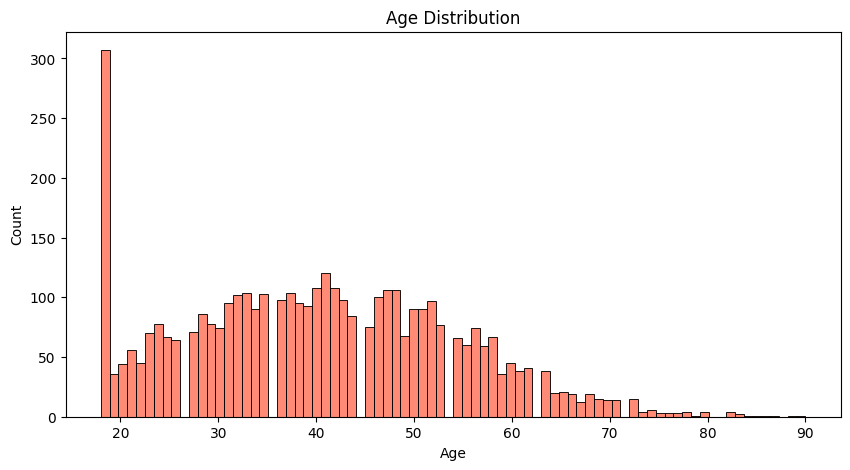

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'].dropna(), bins=80, kde=False, color='tomato')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

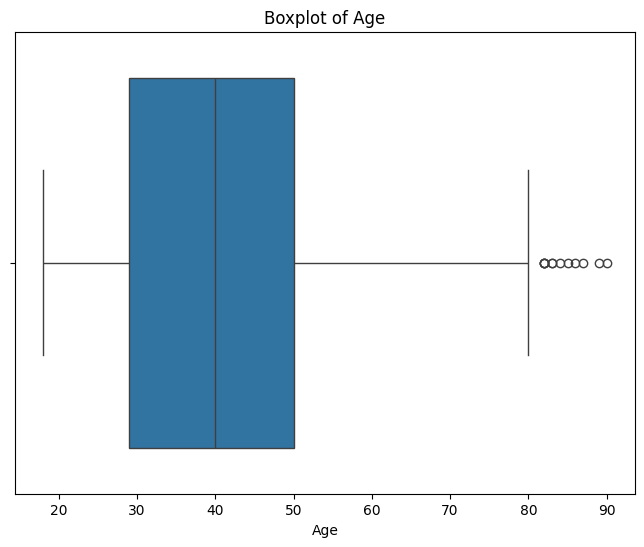

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

In [20]:
df['age'] = df['age'].astype(float)
df_test['age'] = df_test['age'].astype(float)

mean_18_30 = df.loc[(df.age >= 18) & (df.age <= 30), "age"].mean(skipna=True)
mean_30_90 = df.loc[(df.age >= 30) & (df.age <= 90), "age"].mean(skipna=True)

df.loc[df.age < 18, "age"] = mean_18_30
df.loc[df.age > 90, "age"] = mean_30_90
df_test.loc[df_test.age < 18, "age"] = mean_18_30
df_test.loc[df_test.age > 90, "age"] = mean_30_90

In [21]:
print("Min-max age:", df['age'].min(), df['age'].max())

Min-max age: 18.0 90.0


In [22]:
min_age = 18.0
max_age = 90.0
range_age = max_age - min_age

df['age'] = ((df['age'] - min_age) / range_age).round(4)
df_test['age'] = ((df_test['age'] - min_age) / range_age).round(4)

## antiguedad

In [23]:
counts = df['antiguedad'].value_counts(dropna=False)
print(counts)

antiguedad
169    26
216    25
138    25
143    24
20     24
       ..
87      8
105     8
116     8
238     7
30      6
Name: count, Length: 250, dtype: int64


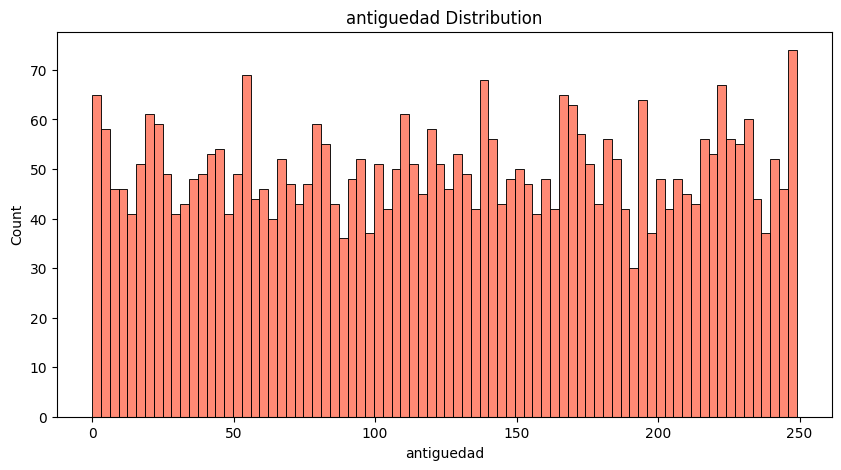

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['antiguedad'].dropna(), bins=80, kde=False, color='tomato')
plt.title('antiguedad Distribution')
plt.xlabel('antiguedad')
plt.ylabel('Count')
plt.show()

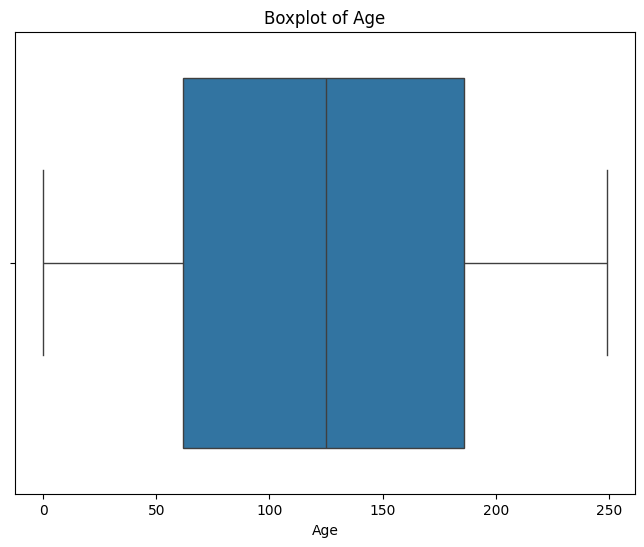

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['antiguedad'])
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

Dễ thấy cột này hoàn toàn không có giá trị outlier.

In [26]:
print("Min-max antiguedad:", df_test['antiguedad'].min(), df_test['antiguedad'].max())

Min-max antiguedad: 1 249


In [27]:
min_antiguedad = 0.0
max_antiguedad = 256.0
range_antiguedad = max_antiguedad - min_antiguedad

df_test.loc[df_test['antiguedad'] > 256.0, 'antiguedad'] = 256.0

df['antiguedad'] = ((df['antiguedad'] - min_antiguedad) / range_antiguedad).round(4)
df_test['antiguedad'] = ((df_test['antiguedad'] - min_antiguedad) / range_antiguedad).round(4)

## renta

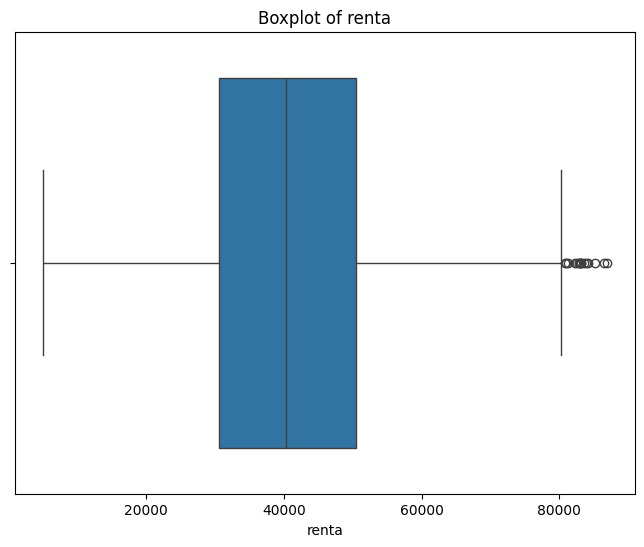

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['renta'])
plt.title('Boxplot of renta')
plt.xlabel('renta')
plt.show()

In [29]:
Q1 = df['renta'].quantile(0.25)
Q3 = df['renta'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
median = df['renta'].median()

# In kết quả
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Median: {median}")
print(f"Lower bound (outlier threshold): {lower_bound}")
print(f"Upper bound (outlier threshold): {upper_bound}")

outliers = df[(df['renta'] < lower_bound) | (df['renta'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values:\n{outliers['renta'].sort_values().values}")


Q1 (25th percentile): 30538.0
Q3 (75th percentile): 50471.0
IQR: 19933.0
Median: 40253.5
Lower bound (outlier threshold): 638.5
Upper bound (outlier threshold): 80370.5
Number of outliers: 16
Outlier values:
[80782 81067 81356 82318 82597 82886 83031 83071 83163 83243 83642 83950
 84202 85233 86561 86911]


In [30]:
print("Min-max train renta:", df_test['renta'].min(), df_test['renta'].max())
print("Min-max test renta:", df['renta'].min(), df['renta'].max())

Min-max train renta: 5000 88217
Min-max test renta: 5000 86911


In [31]:
min_renta = 0.
max_renta = 280000.0
df['renta'] = df['renta'].clip(upper=max_renta)
df_test['renta'] = df_test['renta'].clip(upper=max_renta)
print("Min-max train renta:", df_test['renta'].min(), df_test['renta'].max())
print("Min-max test renta:", df['renta'].min(), df['renta'].max())

Min-max train renta: 5000 88217
Min-max test renta: 5000 86911


In [32]:
range_renta = max_renta - min_renta
df['renta'] = ((df['renta'] - min_renta) / range_renta).round(6)
df_test['renta'] = ((df_test['renta'] - min_renta) / range_renta).round(6)

print("Min-max train renta:", df_test['renta'].min(), df_test['renta'].max())
print("Min-max test renta:", df['renta'].min(), df['renta'].max())

Min-max train renta: 0.017857 0.315061
Min-max test renta: 0.017857 0.310396


In [33]:
df.isnull().sum()

,0
fecha_dato,0
ncodpers,0
ind_empleado,0
pais_residencia,0
sexo,0
age,0
fecha_alta,0
ind_nuevo,0
antiguedad,0
indrel,0


# Label Encoder đối với các cột có dạng category

In [34]:
from sklearn.preprocessing import LabelEncoder

cols = ['ind_empleado','pais_residencia', 'sexo','ind_nuevo','indrel_1mes','tiprel_1mes', 'indresi',
        'indext', 'conyuemp', 'canal_entrada','indfall', 'nomprov','segmento','indrel','ind_actividad_cliente']

label_encoders = {}  # lưu các bộ encoder theo cột

for col in cols:
    le = LabelEncoder()
    # fit trên df[col], chuyển giá trị sang dạng string để tránh lỗi nếu có NA hoặc khác kiểu
    df[col] = df[col].astype(str)
    df_test[col] = df_test[col].astype(str)

    le.fit(df[col])
    df[col] = le.transform(df[col])

    # áp dụng encoder lên df_test
    # với các giá trị không thuộc tập train, transform sẽ lỗi nên ta xử lý thủ công
    # cách đơn giản: map theo dict encoder, giá trị không tìm thấy cho -1 (hoặc 9999 tùy bạn)
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    df_test[col] = df_test[col].map(mapping).fillna(-1).astype(int)

    label_encoders[col] = le

In [35]:
for col in cols:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique encoded values ({len(unique_vals)}): {sorted(unique_vals)}")
    print("------------------------------------------------------")

Column: ind_empleado
Unique encoded values (5): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
------------------------------------------------------
Column: pais_residencia
Unique encoded values (6): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
------------------------------------------------------
Column: sexo
Unique encoded values (2): [np.int64(0), np.int64(1)]
------------------------------------------------------
Column: ind_nuevo
Unique encoded values (2): [np.int64(0), np.int64(1)]
------------------------------------------------------
Column: indrel_1mes
Unique encoded values (5): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
------------------------------------------------------
Column: tiprel_1mes
Unique encoded values (4): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
------------------------------------------------------
Column: indresi
Unique encoded values (2): [np.int64(0), np.int64(1)]
----

In [36]:
for col in cols:
    unique_vals = df_test[col].unique()
    print(f"Column: {col}")
    print(f"Unique encoded values ({len(unique_vals)}): {sorted(unique_vals)}")
    print("------------------------------------------------------")

Column: ind_empleado
Unique encoded values (5): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
------------------------------------------------------
Column: pais_residencia
Unique encoded values (6): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
------------------------------------------------------
Column: sexo
Unique encoded values (2): [np.int64(0), np.int64(1)]
------------------------------------------------------
Column: ind_nuevo
Unique encoded values (2): [np.int64(0), np.int64(1)]
------------------------------------------------------
Column: indrel_1mes
Unique encoded values (5): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
------------------------------------------------------
Column: tiprel_1mes
Unique encoded values (4): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
------------------------------------------------------
Column: indresi
Unique encoded values (2): [np.int64(0), np.int64(1)]
----

ind_nuevo, indrel, ind_actividad_cliente

# FEATURE ENGINEERING

## Loại bỏ 3 đặc trưng tipodom, cod_prov và ult_fec_cli_1t

In [37]:
df.drop(columns=['tipodom', 'cod_prov', 'ult_fec_cli_1t'], inplace=True)
df_test.drop(columns=['tipodom', 'cod_prov', 'ult_fec_cli_1t'], inplace=True)

## Loại bỏ hai sản phẩm ind_ahor_fin_ult1 và ind_aval_fin_ult1 vì hầu như không có người mua mới

In [38]:
df.drop(columns=['ind_ahor_fin_ult1', 'ind_aval_fin_ult1'],inplace = True)

## Thay cột fecha_alta bằng cột days

In [39]:
df['fecha_dato'] = pd.to_datetime(df.fecha_dato)
df['fecha_alta'] = pd.to_datetime(df.fecha_alta)
df_test['fecha_dato'] = pd.to_datetime(df_test.fecha_dato)
df_test['fecha_alta'] = pd.to_datetime(df_test.fecha_alta)
df_days_column = (df['fecha_dato'] - df['fecha_alta']).dt.days
df_test_days_column =  (df_test['fecha_dato'] - df_test['fecha_alta']).dt.days

#generate new column 'days' from
df.insert(loc=6, column='days', value=df_days_column)
df_test.insert(loc=6, column='days', value=df_test_days_column)

#Drop the 'fetch_alta' column
df.drop(columns=['fecha_alta'],inplace = True)
df_test.drop(columns=['fecha_alta'],inplace = True)

In [40]:
df.days.isnull().any()

np.False_

In [41]:
df['days'] = df['days'].fillna(df['days'].mean())
df_test['days'] = df_test['days'].fillna(df['days'].mean())

## Tạo bộ dữ liệu tổng

In [42]:
target_cols = df.columns.values[21:]
target_cols

array(['ind_cco_fin_ult1', 'ind_cder_fin_ult1', 'ind_cno_fin_ult1',
       'ind_ctju_fin_ult1', 'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1',
       'ind_ctpp_fin_ult1', 'ind_deco_fin_ult1', 'ind_deme_fin_ult1',
       'ind_dela_fin_ult1', 'ind_ecue_fin_ult1', 'ind_fond_fin_ult1',
       'ind_hip_fin_ult1', 'ind_plan_fin_ult1', 'ind_pres_fin_ult1',
       'ind_reca_fin_ult1', 'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1',
       'ind_viv_fin_ult1', 'ind_nomina_ult1', 'ind_nom_pens_ult1',
       'ind_recibo_ult1'], dtype=object)

In [43]:
cust5_2015 = df[df['fecha_dato'] == '2015-05-28'].set_index('ncodpers')[target_cols]
id_cust5_2015 = cust5_2015.index.to_numpy()
cust6_in52015 = df[(df['fecha_dato'] == '2015-06-28') & (df['ncodpers'].isin(cust5_2015.index))] \
               .set_index('ncodpers')[target_cols]
subtract_56 = (cust5_2015 - cust6_in52015)
q = (subtract_56[target_cols] == -1).sum(1)
id_cust5_buyin6 = q[q > 0].index

cust5_buyin6 = df[(df['fecha_dato'] == '2015-06-28') & (df['ncodpers'].isin(id_cust5_buyin6))]
cust6_newbuyin6 = df[(df['fecha_dato'] == '2015-06-28') & (~df['ncodpers'].isin(id_cust5_2015))]

## Tạo feature sum_prod_last

In [44]:
import warnings
warnings.filterwarnings('ignore')

train_total = pd.DataFrame()
t=0
for i in tqdm(target_cols):
    train = cust5_buyin6[cust5_buyin6['ncodpers'].isin(subtract_56[subtract_56[i] == -1].index)]
    train2 = cust6_newbuyin6[cust6_newbuyin6[i] == 1]
    train.drop(columns=target_cols,inplace = True)
    train2.drop(columns=target_cols,inplace = True)
    train['target'] = t
    train2['target'] = t

    train = pd.concat([train, train2], ignore_index=True, sort=False)
    train_total = pd.concat([train_total, train], ignore_index=True, sort=False)
    t+=1

del train
del train2
warnings.filterwarnings('default')

100%|██████████| 22/22 [00:00<00:00, 202.27it/s]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [45]:
train_total.head(1)
train_total.shape

(0, 22)

In [46]:
df_total = pd.concat([train_total, df_test], ignore_index=True, sort=False)
df_total

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,days,ind_nuevo,antiguedad,indrel,indrel_1mes,tiprel_1mes,indresi,indext,conyuemp,canal_entrada,indfall,nomprov,ind_actividad_cliente,renta,segmento,target,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,ind_deme_fin_ult1,ind_dela_fin_ult1,ind_ecue_fin_ult1,ind_fond_fin_ult1,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-04-01,1005997,0,1,0,0.0000,-369,0,0.9102,0,0,2,1,0,0,2,0,36,1,0.315061,1,NaN,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,2016-02-01,1000652,0,1,1,0.0000,2793,0,0.1094,0,0,0,1,0,0,1,0,23,0,0.158904,1,NaN,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2016-03-01,1005329,3,1,1,0.1389,5144,0,0.9570,0,0,0,1,0,0,2,0,5,1,0.180429,2,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,2015-02-01,1005166,0,1,1,0.2083,-400,0,0.3203,1,0,0,0,0,0,1,0,45,0,0.138579,1,NaN,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,2015-08-01,1004298,0,1,1,0.2639,5067,0,0.0742,0,2,0,1,0,0,2,0,4,1,0.168575,1,NaN,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2015-11-01,1007396,3,1,0,0.3611,4956,0,0.3047,0,0,0,1,1,0,4,0,38,1,0.263079,1,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
996,2015-06-01,1009029,0,3,1,0.4583,2149,0,0.0234,0,1,0,1,1,0,4,0,17,1,0.186179,1,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
997,2015-11-01,1005077,1,1,1,0.4028,4640,0,0.6445,0,4,1,0,0,0,2,0,49,1,0.125821,2,NaN,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
998,2015-01-01,1000104,4,1,1,0.3056,2893,1,0.0586,0,0,1,1,0,1,0,0,21,1,0.132296,1,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Tạo tập train

In [47]:
X_train = df_total[~df_total['target'].isnull()]
y_train = X_train['target'].astype(int)
X_train.drop(columns=['target'],inplace = True)

train_cust_ids = X_train['ncodpers']
X_train.drop(columns=['fecha_dato','ncodpers'],inplace = True)

X_train = X_train.values.tolist()

/tmp/ipython-input-710859068.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns=['target'],inplace = True)
/tmp/ipython-input-710859068.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns=['fecha_dato','ncodpers'],inplace = True)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Tạo tập test

In [48]:
test_cust_ids = df_total[df_total['target'].isnull()]['ncodpers'].values
X_test = df_total[df_total['target'].isnull()]
X_test.drop(columns=['target'],inplace=True)
X_test.drop(columns=['fecha_dato','ncodpers'],inplace = True)
X_test = X_test.values.tolist()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Tạo 5 feature lag

In [49]:
# Generating 5-lag features for every product

#Train lag features
temp1 = df[(df['fecha_dato'] < '2015-06-28') & (df['ncodpers'].isin(train_total['ncodpers']))]
temp1.drop(columns = ['ind_empleado','pais_residencia','sexo','age','days','ind_nuevo','antiguedad','indrel','indrel_1mes','tiprel_1mes','indresi','indext','conyuemp','canal_entrada','indfall','nomprov','ind_actividad_cliente','renta','segmento'],inplace = True)

train_lags = {}
for i in tqdm(temp1.itertuples()):
    if i[2] not in train_lags.keys():
        train_lags[i[2]] = []
    train_lags[i[2]].append(np.array(i[3:]).astype(int))


#Test lag features
temp2 = df[(df['fecha_dato'] < '2016-06-28') & (df['fecha_dato'] >= '2016-01-28') & (df['ncodpers'].isin(df_test['ncodpers']))]
temp2.drop(columns = ['ind_empleado','pais_residencia','sexo','age','days','ind_nuevo','antiguedad','indrel','indrel_1mes','tiprel_1mes','indresi','indext','conyuemp','canal_entrada','indfall','nomprov','ind_actividad_cliente','renta','segmento'],inplace = True)

test_lags = {}
for i in tqdm(temp2.itertuples()):
    if i[2] not in test_lags.keys():
        test_lags[i[2]] = []
    test_lags[i[2]].append(np.array(i[3:]).astype(int))


#Creating the final train dataset
X_train = df_total[~df_total['target'].isnull()]
y_train = X_train['target'].astype(int)
X_train.drop(columns=['target'],inplace = True)

train_cust_ids = X_train['ncodpers']
X_train.drop(columns=['fecha_dato','ncodpers'],inplace = True)

X_train = X_train.values.tolist()

#Adding the lag variables to the train dataset
k=0
for i in tqdm(train_cust_ids):
    l = train_lags.get(i,[[0]*22])

    try:
        lag_1 = list(l[-1])
    except:
        lag_1 = [0]*22
    try:
        lag_2 = list(l[-2])
    except:
        lag_2 = [0]*22
    try:
        lag_3 = list(l[-3])
    except:
        lag_3 = [0]*22
    try:
        lag_4 = list(l[-4])
    except:
        lag_4 = [0]*22
    try:
        lag_5 = list(l[-5])
    except:
        lag_5 = [0]*22

    X_train[k].extend(lag_1+lag_5+lag_4+lag_3+lag_2)
    k+=1

X_train = np.array(X_train)

##Creating the final test dataset
test_cust_ids = df_total[df_total['target'].isnull()]['ncodpers'].values
X_test = df_total[df_total['target'].isnull()]
X_test.drop(columns=['target'],inplace=True)
X_test.drop(columns=['fecha_dato','ncodpers'],inplace = True)
X_test = X_test.values.tolist()

X_test_new = []

#Adding the lag variables to the test dataset
k=0
for i in tqdm(test_cust_ids):
    l = test_lags.get(i,[[0]*22])

    try:
        lag_1 = list(l[-1])
    except:
        lag_1 = [0]*22
    try:
        lag_2 = list(l[-2])
    except:
        lag_2 = [0]*22
    try:
        lag_3 = list(l[-3])
    except:
        lag_3 = [0]*22
    try:
        lag_4 = list(l[-4])
    except:
        lag_4 = [0]*22
    try:
        lag_5 = list(l[-5])
    except:
        lag_5 = [0]*22

    X_test_new.append(np.array(X_test[k] + lag_1 + lag_5 + lag_4 +lag_3 + lag_2))
    k+=1


X_test = X_test_new


/tmp/ipython-input-88648538.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp1.drop(columns = ['ind_empleado','pais_residencia','sexo','age','days','ind_nuevo','antiguedad','indrel','indrel_1mes','tiprel_1mes','indresi','indext','conyuemp','canal_entrada','indfall','nomprov','ind_actividad_cliente','renta','segmento'],inplace = True)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
0it [00:00, ?it/s]
/tmp/ipython-input-88648538.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See

## HYPER PARAMETER TUNING FOR XGBOOST

In [57]:
df_test.shape

(4000, 43)

In [55]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

# Tham số cho từng thuật toán
params_xgb = {
    'learning_rate': [0.01, 0.03, 0.1, 0.2],
    'max_depth': [3, 5, 8],
    'n_estimators': [10, 50],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1],
    'min_child_weight': [1, 3, 5, 7, 10, 14]
}

params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

params_cat = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

params_lgbm = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'min_child_samples': [10, 20, 30]
}

# List model + params để chạy vòng lặp
models = [
    ('XGB', XGBClassifier(objective='multi:softprob', eval_metric='mlogloss'), params_xgb),
    ('RF', RandomForestClassifier(), params_rf),
    ('CatBoost', CatBoostClassifier(verbose=0, loss_function='MultiClass'), params_cat),
    ('LGBM', LGBMClassifier(objective='multiclass'), params_lgbm)
]

best_estimators = {}
for name, model, params in models:
    print(f"Running RandomizedSearchCV for {name}...")
    clf = RandomizedSearchCV(model, params, n_iter=15, scoring='roc_auc_ovo', cv=3, n_jobs=-1, verbose=10, return_train_score=True, error_score='raise')
    clf.fit(X_train, y_train)
    print(f"Best parameters found for {name}: {clf.best_params_}")
    best_estimators[name] = clf.best_estimator_

Running RandomizedSearchCV for XGB...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
clf.best_params_

In [ ]:
#best hyperparameters
from xgboost.sklearn import XGBClassifier
xgb = XGBClassifier(objective = 'multi:softprob',eval_metric = 'mlogloss',max_depth=3,n_estimators=50,learning_rate=0.03,colsample_bytree=0.8,subsample=0.9,min_child_weight = 1)
xgb.fit(X_train, y_train)

y_pred = xgb.predict_proba(X_test)

#Finding the new products to be predicted by test users
test_users = {}
for i in tqdm(df[(df['fecha_dato'] == '2016-05-28') & (df['ncodpers'].isin(df_test['ncodpers'].to_numpy()))].iloc):
    test_users[i['ncodpers']] = np.where(i['ind_cco_fin_ult1':'ind_recibo_ult1'] == 0)[0]


test_user_ratings = {}
k=0
for i in tqdm(test_cust_ids):
    test_user_ratings[i] = y_pred[k][test_users[i]]
    k+=1

final_preds = []
test_ids = []
for i in tqdm(test_user_ratings.keys()):
    top_seven = test_users[i][np.argsort(test_user_ratings[i])[::-1][:7]]
    final_preds.append(" ".join(target_cols[top_seven]))
    test_ids.append(i)

In [ ]:
xgb_submission = pd.DataFrame({'ncodpers':test_ids, 'added_products':final_preds})
xgb_submission = xgb_submission.sort_values('ncodpers')
xgb_submission.to_csv('submission.csv', index=False)